# 02. Кластеризация по энергоёмкости породы

**Вход:** `preprocessed.csv`  
**Выход:** `clustered.csv` (+ столбец `cluster`)


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

## Настраиваемые параметры

In [10]:
INPUT_FILE = 'preprocessed.csv'
OUTPUT_FILE = 'clustered.csv'
N_CLUSTERS = 7
RANDOM_STATE = 21

## 1. Загрузка

In [11]:
df = pd.read_csv(INPUT_FILE)
X = df[['log_EI']].values
X_scaled = StandardScaler().fit_transform(X)

np.random.seed(RANDOM_STATE)
sil_idx = np.random.choice(len(X), size=min(20000, len(X)), replace=False)

## 2. GMM: BIC / AIC

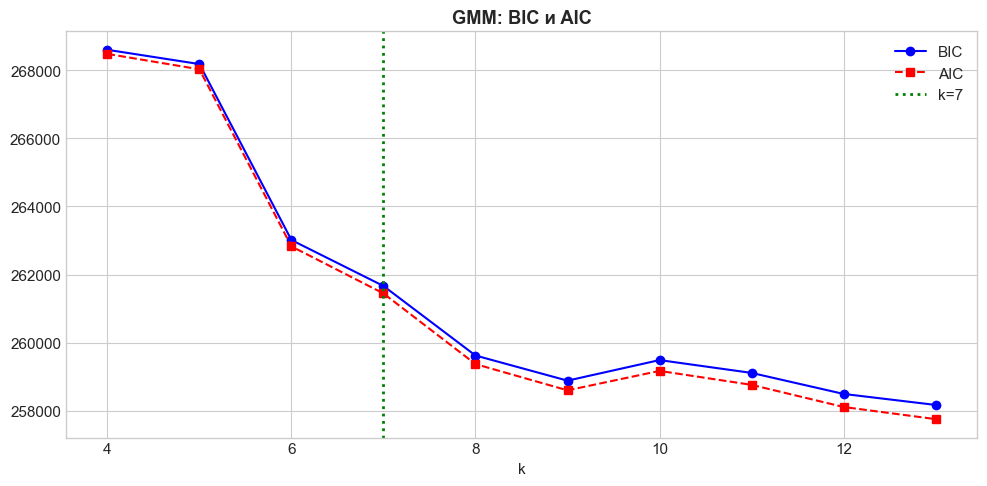

In [12]:
gm_results = []
for k in range(4, 14):
    gm = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=3)
    gm.fit(X)
    gm_results.append({'k': k, 'bic': gm.bic(X), 'aic': gm.aic(X)})

gr = pd.DataFrame(gm_results)
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(gr['k'], gr['bic'], 'bo-', label='BIC')
ax.plot(gr['k'], gr['aic'], 'rs--', label='AIC')
ax.axvline(x=N_CLUSTERS, color='green', linestyle=':', linewidth=2, label=f'k={N_CLUSTERS}')
ax.set_xlabel('k')
ax.set_title('GMM: BIC и AIC', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

## 3. Финальная кластеризация — GMM

In [13]:
gm_final = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE, n_init=5)
df['cluster'] = gm_final.fit_predict(X)

order = df.groupby('cluster')['log_EI'].mean().sort_values().index.tolist()
remap = {old: new for new, old in enumerate(order)}
df['cluster'] = df['cluster'].map(remap)
df['cluster_prob'] = gm_final.predict_proba(X).max(axis=1)

COLORS = ['#22c55e','#84cc16',"#e9ff24",'#f59e0b','#ef4444',"#00aeff",'#7c3aed'][:N_CLUSTERS]

profiles = []
for c in range(N_CLUSTERS):
    s = df[df['cluster']==c]
    profiles.append({
        'Кластер': c,
        'Записей': len(s),
        'Скважин': s['well_id'].nunique(),
        'log_EI μ': round(s['log_EI'].mean(), 2),
        'v_mean': round(s['speed'].mean(), 5),
        'P_ос': round(s['pressure_axis'].mean(), 0),
        'P_вр': round(s['pressure_rotation'].mean(), 0),
        'prob μ': round(s['cluster_prob'].mean(), 3),
    })

pd.DataFrame(profiles).set_index('Кластер')

,Записей,Скважин,log_EI μ,v_mean,P_ос,P_вр,prob μ
Кластер,,,,,,,
0,12772,1474,11.15,0.02780,5062.0,7951.0,0.870
1,30522,1636,11.70,0.01850,9249.0,9795.0,0.766
2,66351,1715,12.05,0.01828,15116.0,12843.0,0.773
3,124006,1718,12.28,0.01554,18513.0,15021.0,0.766
4,117369,1664,12.47,0.01098,19552.0,15295.0,0.794
5,69910,1555,12.72,0.00601,19523.0,14660.0,0.886
6,6270,892,13.27,0.00707,17960.0,14109.0,0.932


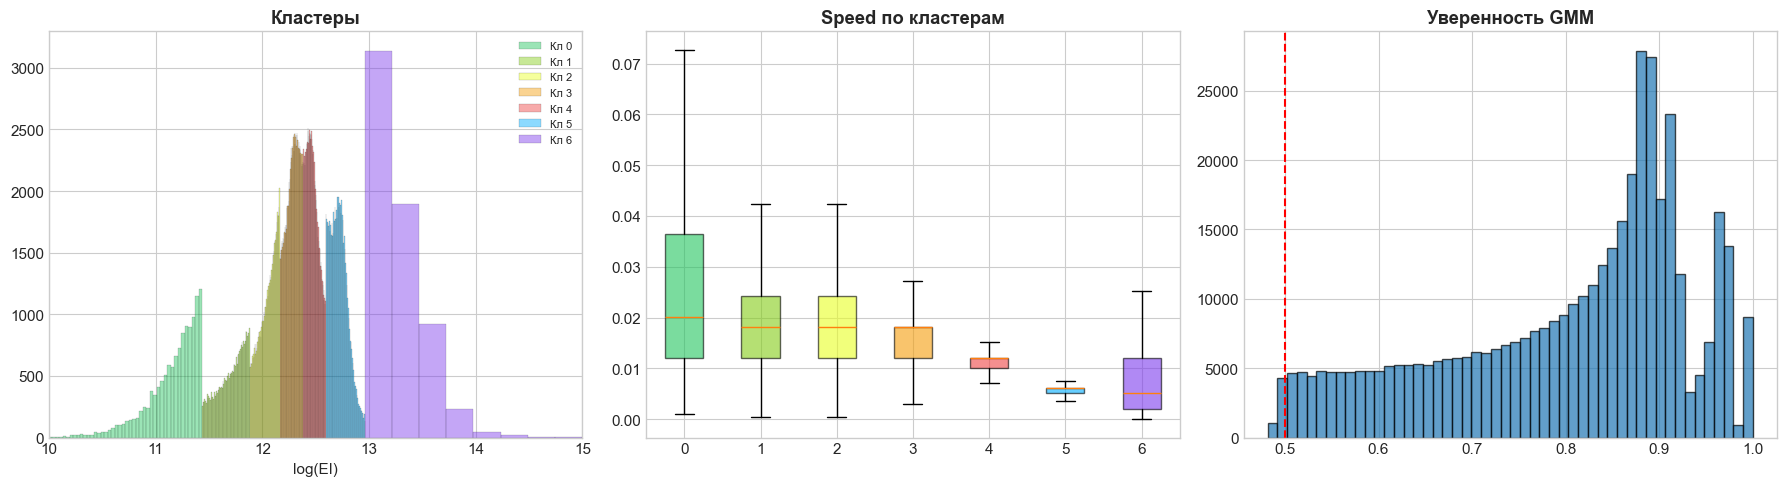

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for c in range(N_CLUSTERS):
    s = df[df['cluster']==c]
    axes[0].hist(s['log_EI'], bins=60, alpha=0.45, color=COLORS[c], edgecolor='black', linewidth=0.2, label=f'Кл {c}')

axes[0].set_xlabel('log(EI)'); axes[0].set_title('Кластеры', fontweight='bold'); axes[0].legend(fontsize=8)
axes[0].set_xlim(10, 15)
bp = axes[1].boxplot([df[df['cluster']==c]['speed'].values for c in range(N_CLUSTERS)], labels=[str(c) for c in range(N_CLUSTERS)], patch_artist=True, showfliers=False)

for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title('Speed по кластерам', fontweight='bold')

axes[2].hist(df['cluster_prob'], bins=50, edgecolor='black', alpha=0.7)
axes[2].set_title('Уверенность GMM', fontweight='bold')
axes[2].axvline(0.5, color='red', linestyle='--')

plt.tight_layout()
plt.show()

## 4. Готовность к GroupKFold

In [15]:
print(f'\n Скважин в каждом кластере:')
for c in range(N_CLUSTERS):
    s = df[df['cluster']==c]
    print(f'  Кл {c}: {s["well_id"].nunique()} скважин, {len(s)} записей')


 Скважин в каждом кластере:
  Кл 0: 1474 скважин, 12772 записей
  Кл 1: 1636 скважин, 30522 записей
  Кл 2: 1715 скважин, 66351 записей
  Кл 3: 1718 скважин, 124006 записей
  Кл 4: 1664 скважин, 117369 записей
  Кл 5: 1555 скважин, 69910 записей
  Кл 6: 892 скважин, 6270 записей


## 5. Сохранение

In [16]:
df.to_csv(OUTPUT_FILE, index=False)